# 25. Strategy Validation and Stress Testing

## Objective
Validate whether Step-24 performance is real and robust through strict alignment checks, walk-forward testing, randomization, bootstrap simulation, and stress scenarios.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 320)
pd.set_option('display.width', 240)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-31')

MAX_TRADES_PER_DAY = 10
STOP_LOSS = -0.02
TAKE_PROFIT = 0.04
REGIME_CAPITAL = {'MEDIUM': 0.70, 'HIGH': 0.30}
BASE_TX_COST = 0.001
ANNUALIZATION_DAYS = 252
BOOTSTRAP_SIMS = 1000
RANDOM_STATE = 42

logger = logging.getLogger('strategy_validation_stress')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'

STEP24_PATH = BASE / 'Market_Data' / 'final' / 'final_risk_managed_strategy.parquet'
STEP23_PATH = BASE / 'Market_Data' / 'final' / 'final_regime_aware_strategy.parquet'
STEP20_PATH = BASE / 'Market_Data' / 'final' / 'final_strategy_results.parquet'
PROCESSED_PATH = BASE / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
OUT_PATH = BASE / 'Market_Data' / 'final' / 'validated_strategy_results.parquet'

assert STEP24_PATH.exists(), f'Missing Step-24 output: {STEP24_PATH}'
assert STEP23_PATH.exists(), f'Missing Step-23 output: {STEP23_PATH}'
assert STEP20_PATH.exists(), f'Missing Step-20 output: {STEP20_PATH}'
assert PROCESSED_PATH.exists(), f'Missing processed dataset: {PROCESSED_PATH}'

step24 = pd.read_parquet(STEP24_PATH).copy()
step23 = pd.read_parquet(STEP23_PATH).copy()
step20 = pd.read_parquet(STEP20_PATH).copy()
market = pd.read_parquet(PROCESSED_PATH, columns=['Ticker', 'Date', 'Close', 'Volatility_20']).copy()

for df in [step24, step23, step20, market]:
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])

step24['regime_label'] = step24['regime_label'].astype(str).str.upper()
step23['regime_label'] = step23['regime_label'].astype(str).str.upper()
market['Ticker'] = market['Ticker'].astype(str)
market = market.sort_values(['Ticker', 'Date']).reset_index(drop=True)

for h in [1, 3, 5]:
    market[f'ret_t{h}'] = market.groupby('Ticker', sort=False)['Close'].shift(-h) / market['Close'] - 1.0

# STEP 1: STRICT TIME ALIGNMENT CHECK
# Step-23 check using horizon_days directly.
step23_check = step23.merge(market[['Ticker', 'Date', 'ret_t1', 'ret_t3', 'ret_t5']], on=['Ticker', 'Date'], how='left')
step23_check = step23_check.dropna(subset=['future_return'])
step23_check['expected_future_return'] = np.select(
    [
        step23_check['horizon_days'] == 1,
        step23_check['horizon_days'] == 3,
        step23_check['horizon_days'] == 5,
    ],
    [
        step23_check['ret_t1'],
        step23_check['ret_t3'],
        step23_check['ret_t5'],
    ],
    default=np.nan,
)
assert step23_check['horizon_days'].ge(1).all(), 'Found non-positive horizon in Step-23.'
assert np.allclose(
    step23_check['future_return'].to_numpy(),
    step23_check['expected_future_return'].to_numpy(),
    atol=1e-12,
    equal_nan=False,
), 'Step-23 future_return is not strictly aligned to forward returns.'

# Step-24 check via regime-implied horizon (MEDIUM=t+3, HIGH=t+1).
step24_check = step24.merge(market[['Ticker', 'Date', 'ret_t1', 'ret_t3']], on=['Ticker', 'Date'], how='left')
step24_check = step24_check.dropna(subset=['future_return'])
step24_check['implied_horizon'] = step24_check['regime_label'].map({'HIGH': 1, 'MEDIUM': 3})
step24_check['expected_future_return'] = np.where(
    step24_check['implied_horizon'] == 1,
    step24_check['ret_t1'],
    step24_check['ret_t3'],
)
assert step24_check['implied_horizon'].isin([1, 3]).all(), 'Unexpected regime in Step-24 for validation.'
assert np.allclose(
    step24_check['future_return'].to_numpy(),
    step24_check['expected_future_return'].to_numpy(),
    atol=1e-12,
    equal_nan=False,
), 'Step-24 future_return is not strictly aligned to forward returns.'

print('Strict time alignment checks passed: signal at t, return from t+1 onward only.')
logger.info('Loaded rows | Step24=%s, Step23=%s, Step20=%s', f'{len(step24):,}', f'{len(step23):,}', f'{len(step20):,}')


[INFO] Loaded rows | Step24=802, Step23=22,643, Step20=21,792


Strict time alignment checks passed: signal at t, return from t+1 onward only.


In [3]:
def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def summarize_daily(name: str, daily_returns: pd.Series) -> Dict[str, float]:
    s = daily_returns.sort_index()
    if len(s) == 0:
        return {
            'Strategy': name,
            'Total return': np.nan,
            'Sharpe ratio': np.nan,
            'Max drawdown': np.nan,
            'Win rate': np.nan,
            'Annualized volatility': np.nan,
            'Daily VaR(95%)': np.nan,
        }
    eq = (1.0 + s).cumprod()
    return {
        'Strategy': name,
        'Total return': float(eq.iloc[-1] - 1.0),
        'Sharpe ratio': sharpe_ratio(s),
        'Max drawdown': max_drawdown(eq),
        'Win rate': float((s > 0).mean()),
        'Annualized volatility': float(s.std(ddof=1) * np.sqrt(ANNUALIZATION_DAYS)),
        'Daily VaR(95%)': float(s.quantile(0.05)),
    }


def build_candidates(step23_df: pd.DataFrame, market_df: pd.DataFrame) -> pd.DataFrame:
    df = step23_df.copy()
    if 'selected_trade' in df.columns:
        df = df[df['selected_trade']].copy()
    df = df[df['regime_label'].isin(['MEDIUM', 'HIGH'])].copy()
    df['signal_strength'] = (df['probability'] - 0.5).abs()
    vol = market_df[['Ticker', 'Date', 'Volatility_20']].copy()
    out = df.merge(vol, on=['Ticker', 'Date'], how='left')
    out['Volatility_20'] = out['Volatility_20'].replace(0, np.nan)
    out['Volatility_20'] = out['Volatility_20'].fillna(out['Volatility_20'].median())
    out['Volatility_20'] = out['Volatility_20'].clip(lower=1e-6)
    out['capital_fraction'] = out['regime_label'].map(REGIME_CAPITAL).astype(float)
    return out


def run_risk_pipeline(
    candidate_df: pd.DataFrame,
    tx_cost: float = BASE_TX_COST,
    slippage: float = 0.0,
    randomize_signals: bool = False,
    random_state: int = RANDOM_STATE,
    regime_subset: Optional[Sequence[str]] = None,
) -> Tuple[pd.DataFrame, pd.Series]:
    df = candidate_df.copy()
    if regime_subset is not None:
        allowed = {str(x).upper() for x in regime_subset}
        df = df[df['regime_label'].isin(allowed)].copy()

    if randomize_signals:
        rng = np.random.default_rng(random_state)
        perm = rng.permutation(len(df))
        df['probability'] = df['probability'].to_numpy()[perm]
        df['signal_strength'] = (df['probability'] - 0.5).abs()

    df = df.sort_values(['Date', 'signal_strength'], ascending=[True, False]).copy()
    df['rank_in_day'] = df.groupby('Date').cumcount() + 1
    df['selected_trade'] = df['rank_in_day'] <= MAX_TRADES_PER_DAY
    df = df[df['selected_trade']].copy()

    if len(df) == 0:
        return df, pd.Series(dtype=float)

    df['direction'] = np.where(df['probability'] > 0.5, 1, np.where(df['probability'] < 0.5, -1, 0))
    df['vol_scaled_signal'] = df['signal_strength'] / df['Volatility_20']
    df['alloc_score'] = df['capital_fraction'] * df['vol_scaled_signal']
    df['alloc_sum'] = df.groupby('Date')['alloc_score'].transform('sum')
    df['weight_abs'] = np.where(df['alloc_sum'] > 0, df['alloc_score'] / df['alloc_sum'], 0.0)
    df['weight'] = df['weight_abs'] * df['direction']

    df['unit_trade_return'] = df['direction'] * df['future_return']
    df['unit_trade_return_risk_managed'] = df['unit_trade_return'].clip(lower=STOP_LOSS, upper=TAKE_PROFIT)
    df['gross_return'] = df['weight_abs'] * df['unit_trade_return_risk_managed']
    df['txn_cost'] = tx_cost * df['weight'].abs()
    df['slippage_cost'] = slippage * df['weight'].abs()
    df['strategy_return_net'] = df['gross_return'] - df['txn_cost'] - df['slippage_cost']

    daily = df.groupby('Date', as_index=True)['strategy_return_net'].sum().sort_index()
    return df, daily


candidates = build_candidates(step23, market)

# STEP 2: WALK-FORWARD BACKTEST (train split defined, full pipeline run only on test)
train_candidates = candidates[(candidates['Date'] >= TRAIN_START) & (candidates['Date'] <= TRAIN_END)].copy()
test_candidates = candidates[(candidates['Date'] >= TEST_START) & (candidates['Date'] <= TEST_END)].copy()
assert len(test_candidates) > 0, 'No test candidates available for 2025 walk-forward test.'
assert test_candidates['Date'].dt.year.eq(2025).all(), 'Walk-forward test set contains non-2025 rows.'

baseline_trades, baseline_daily = run_risk_pipeline(test_candidates, tx_cost=BASE_TX_COST, slippage=0.0)
assert len(baseline_daily) > 0, 'Baseline walk-forward daily returns are empty.'

daily_step20 = (
    step20[(step20['Date'] >= TEST_START) & (step20['Date'] <= TEST_END)]
    .groupby('Date', as_index=True)['net_return']
    .sum()
    .sort_index()
)
daily_step23 = (
    step23[(step23['Date'] >= TEST_START) & (step23['Date'] <= TEST_END)]
    .groupby('Date', as_index=True)['strategy_return']
    .sum()
    .sort_index()
)
daily_bh = (
    market[(market['Date'] >= TEST_START) & (market['Date'] <= TEST_END)]
    .dropna(subset=['ret_t1'])
    .groupby('Date', as_index=True)['ret_t1']
    .mean()
    .sort_index()
)

common = baseline_daily.index.intersection(daily_step20.index).intersection(daily_step23.index).intersection(daily_bh.index)
cmp_base = baseline_daily.loc[common]
cmp_step20 = daily_step20.loc[common]
cmp_step23 = daily_step23.loc[common]
cmp_bh = daily_bh.loc[common]

benchmark_metrics = pd.DataFrame([
    summarize_daily('Step-24 validated (walk-forward test)', cmp_base),
    summarize_daily('Step-20 strategy', cmp_step20),
    summarize_daily('Step-23 strategy', cmp_step23),
    summarize_daily('Buy & Hold', cmp_bh),
]).sort_values('Sharpe ratio', ascending=False).reset_index(drop=True)
display(benchmark_metrics.round(4))


,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate,Annualized volatility,Daily VaR(95%)
0,Step-24 validated (walk-forward test),0.5665,2.8237,-0.0965,0.5189,0.2257,-0.0188
1,Step-20 strategy,0.1119,2.5821,0.0000,0.0324,0.0566,0.0000
2,Buy & Hold,0.2395,2.0541,-0.0868,0.5838,0.1477,-0.0142
3,Step-23 strategy,0.0775,0.5309,-0.1858,0.5405,0.2499,-0.0273


,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate,Annualized volatility,Daily VaR(95%)
0,Original signals,0.8552,3.3885,-0.0965,0.5320,0.2348,-0.0188
1,Randomized signals,0.8272,3.6673,-0.0765,0.5764,0.2103,-0.0167


,Bootstrap simulations,Mean Sharpe,Sharpe CI 2.5%,Sharpe CI 97.5%
0,1000,3.6879,1.8064,5.5804


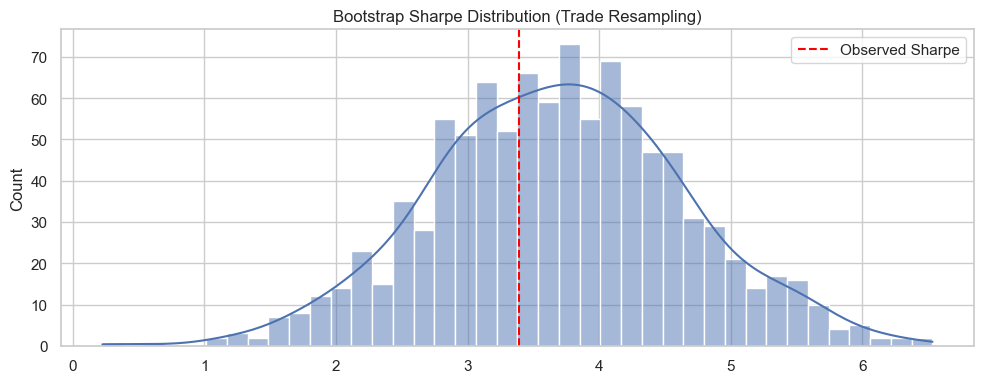

,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate
0,TX cost 0.1%,0.8552,3.3885,-0.0965,0.5320
1,TX cost 0.3%,0.2371,1.2417,-0.1507,0.4877
2,TX cost 0.5%,-0.1757,-0.9051,-0.3637,0.4236


,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate
0,Slippage 0.1%,0.5151,2.3151,-0.1198,0.5074
1,Slippage 0.2%,0.2371,1.2417,-0.1507,0.4877
2,Slippage 0.3%,0.0099,0.1683,-0.2507,0.4532


,Average daily turnover,Median daily turnover,Average holding period (days)
0,0.7974,0.8225,1.3639


,Regime,Total return,Sharpe ratio,Max drawdown,Win rate
0,MEDIUM,0.7628,3.1797,-0.0965,0.5274
1,HIGH,0.0524,22.3590,0.0000,1.0000


In [4]:
# STEP 3: RANDOMIZATION TEST
rand_trades, rand_daily = run_risk_pipeline(
    test_candidates,
    tx_cost=BASE_TX_COST,
    slippage=0.0,
    randomize_signals=True,
    random_state=RANDOM_STATE,
)
randomization_metrics = pd.DataFrame([
    summarize_daily('Original signals', baseline_daily),
    summarize_daily('Randomized signals', rand_daily),
])
display(randomization_metrics.round(4))

# STEP 4: BOOTSTRAP TEST (trade resampling)
bootstrap_sharpes: list[float] = []
counts = baseline_trades.groupby('Date').size().to_numpy()
bucket_idx = np.repeat(np.arange(len(counts)), counts)
for i in range(BOOTSTRAP_SIMS):
    sampled = baseline_trades['strategy_return_net'].sample(
        n=len(baseline_trades),
        replace=True,
        random_state=RANDOM_STATE + i,
    ).to_numpy()
    pseudo_daily = pd.Series(sampled).groupby(bucket_idx).sum()
    bootstrap_sharpes.append(sharpe_ratio(pseudo_daily))

bootstrap_sharpes = pd.Series(bootstrap_sharpes, dtype=float)
bootstrap_summary = pd.DataFrame([
    {
        'Bootstrap simulations': BOOTSTRAP_SIMS,
        'Mean Sharpe': float(bootstrap_sharpes.mean()),
        'Sharpe CI 2.5%': float(bootstrap_sharpes.quantile(0.025)),
        'Sharpe CI 97.5%': float(bootstrap_sharpes.quantile(0.975)),
    }
])
display(bootstrap_summary.round(4))

plt.figure(figsize=(10, 4))
sns.histplot(bootstrap_sharpes.dropna(), bins=40, kde=True)
plt.axvline(float(sharpe_ratio(baseline_daily)), color='red', linestyle='--', linewidth=1.5, label='Observed Sharpe')
plt.title('Bootstrap Sharpe Distribution (Trade Resampling)')
plt.legend()
plt.tight_layout()
plt.show()

# STEP 5: TRANSACTION COST STRESS
tx_rows = []
for cost in [0.001, 0.003, 0.005]:
    _, d = run_risk_pipeline(test_candidates, tx_cost=cost, slippage=0.0)
    rec = summarize_daily(f'TX cost {cost:.1%}', d)
    rec['tx_cost'] = cost
    tx_rows.append(rec)
tx_stress = pd.DataFrame(tx_rows).sort_values('tx_cost').reset_index(drop=True)
display(tx_stress[['Strategy', 'Total return', 'Sharpe ratio', 'Max drawdown', 'Win rate']].round(4))

# STEP 6: SLIPPAGE TEST
slippage_rows = []
for slip in [0.001, 0.002, 0.003]:
    _, d = run_risk_pipeline(test_candidates, tx_cost=BASE_TX_COST, slippage=slip)
    rec = summarize_daily(f'Slippage {slip:.1%}', d)
    rec['slippage'] = slip
    slippage_rows.append(rec)
slippage_stress = pd.DataFrame(slippage_rows).sort_values('slippage').reset_index(drop=True)
display(slippage_stress[['Strategy', 'Total return', 'Sharpe ratio', 'Max drawdown', 'Win rate']].round(4))

# STEP 7: TURNOVER ANALYSIS
weights = baseline_trades.pivot_table(index='Date', columns='Ticker', values='weight', aggfunc='sum').fillna(0.0).sort_index()
daily_turnover = 0.5 * (weights - weights.shift(1).fillna(0.0)).abs().sum(axis=1)

active = baseline_trades.loc[baseline_trades['weight'].abs() > 0, ['Ticker', 'Date']].drop_duplicates().sort_values(['Ticker', 'Date'])
date_index = pd.Index(sorted(weights.index.unique()))
date_to_pos = {d: i for i, d in enumerate(date_index)}
holding_runs = []
for _, g in active.groupby('Ticker', sort=False):
    pos = g['Date'].map(date_to_pos).to_numpy()
    if len(pos) == 0:
        continue
    run = 1
    for j in range(1, len(pos)):
        if pos[j] == pos[j - 1] + 1:
            run += 1
        else:
            holding_runs.append(run)
            run = 1
    holding_runs.append(run)

turnover_summary = pd.DataFrame([
    {
        'Average daily turnover': float(daily_turnover.mean()),
        'Median daily turnover': float(daily_turnover.median()),
        'Average holding period (days)': float(np.mean(holding_runs)) if holding_runs else np.nan,
    }
])
display(turnover_summary.round(4))

# STEP 8: REGIME ROBUSTNESS
regime_rows = []
for reg in ['MEDIUM', 'HIGH']:
    _, d = run_risk_pipeline(test_candidates, tx_cost=BASE_TX_COST, slippage=0.0, regime_subset=[reg])
    rec = summarize_daily(f'{reg} only', d)
    rec['Regime'] = reg
    regime_rows.append(rec)
regime_robustness = pd.DataFrame(regime_rows)
display(regime_robustness[['Regime', 'Total return', 'Sharpe ratio', 'Max drawdown', 'Win rate']].round(4))


In [5]:
# STEP 9: OUTPUT
true_sharpe = float(sharpe_ratio(baseline_daily))

# Adjusted return under stressed assumptions: 0.3% tx cost + 0.2% slippage.
adj_trades, adj_daily = run_risk_pipeline(test_candidates, tx_cost=0.003, slippage=0.002)
adjusted_metrics = summarize_daily('Adjusted scenario', adj_daily)

risk_metrics_view = benchmark_metrics.loc[
    benchmark_metrics['Strategy'] == 'Step-24 validated (walk-forward test)',
    ['Total return', 'Sharpe ratio', 'Max drawdown', 'Win rate', 'Annualized volatility', 'Daily VaR(95%)'],
].reset_index(drop=True)

print(f'True Sharpe (validated): {true_sharpe:.4f}')
print(f"Adjusted return (tx=0.3%, slippage=0.2%): {adjusted_metrics['Total return']:.4f}")
print('Risk metrics (validated baseline):')
display(risk_metrics_view.round(4))

baseline_daily_map = baseline_daily.to_dict()
validated_out = baseline_trades.copy()
validated_out['daily_portfolio_return'] = validated_out['Date'].map(baseline_daily_map)
validated_out['validation_period'] = 'test_2025'
validated_out['time_alignment_validated'] = True
validated_out['tx_cost_used'] = BASE_TX_COST
validated_out['slippage_used'] = 0.0

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
validated_out.to_parquet(OUT_PATH, index=False)

print(f'Saved validated strategy results: {OUT_PATH}')
print('Notebook 25 completed: strategy validation and stress testing done.')


True Sharpe (validated): 3.3885
Adjusted return (tx=0.3%, slippage=0.2%): -0.1757
Risk metrics (validated baseline):


,Total return,Sharpe ratio,Max drawdown,Win rate,Annualized volatility,Daily VaR(95%)
0,0.5665,2.8237,-0.0965,0.5189,0.2257,-0.0188


Saved validated strategy results: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\validated_strategy_results.parquet
Notebook 25 completed: strategy validation and stress testing done.
